# Feature Selection Lab Solutions
**Q1**   
Apply filter-based feature selection with Information Gain to identify the 3 most discriminating and 3 least discriminating features in the Wine dataset.  
Based on these results, assess the 10-fold cross-validation classification accuracy of a 1-Nearest Neighbour classifier with: 
1. only the 3 most discriminating features included
2. only the 3 least discriminating features included 


In [1]:
import pandas as pd
from sklearn.feature_selection import chi2
from sklearn.feature_selection import mutual_info_classif

In [2]:
wine_DF = pd.read_csv('wine.csv')
print(wine_DF.shape)
wine_DF.head()

(178, 14)


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
y = wine_DF.pop('Wine').values
X = wine_DF.values
wine_DF.shape

(178, 13)

In [4]:
i_scores = mutual_info_classif(X,y)

Put the I-Gain scores in a dataframe and sort. 

In [5]:
FS_DF = pd.DataFrame(i_scores,index = wine_DF.columns, columns =['I-Gain'])
FS_DF.sort_values(by=['I-Gain'],ascending=False,inplace=True)
FS_DF

,I-Gain
Flavanoids,0.666440
Proline,0.557009
Color.int,0.551680
OD,0.515843
Alcohol,0.479671
Hue,0.444312
Phenols,0.397451
Proanth,0.287005
Malic.acid,0.274669
Acl,0.238170


Generate top 3 and bottom 3 dataframes and produce the corresponding X (numpy) arrays.

In [6]:
top3_DF = wine_DF[FS_DF.index[:3]]
bottom3_DF = wine_DF[FS_DF.index[-3:]]
X_top3 = top3_DF.values
X_bottom3 = bottom3_DF.values

In [8]:
from sklearn.neighbors import KNeighborsClassifier
kNN = KNeighborsClassifier(n_neighbors=1)

In [9]:
X_bottom3.shape

(178, 3)

In [10]:
from sklearn.model_selection import cross_val_score
knn_bottom = cross_val_score(kNN, X_bottom3, y, cv=10)
print("10x CV Accuracy Bottom 3 features: {0:.2f}".format(knn_bottom.mean())) 

10x CV Accuracy Bottom 3 features: 0.49


In [11]:
knn_top = cross_val_score(kNN, X_top3, y, cv=10)
print("10x CV Accuracy Top 3 features: {0:.2f}".format(knn_top.mean())) 

10x CV Accuracy Top 3 features: 0.78


---
**Q2**  
Using **mlxtend**, identify informative feature subsets by applying wrapper-based feature selection to the Wine dataset using a 3-Nearest Neighbour classifier and the following search strategies: 
- forward sequential search 
- backward elimination search  
  
Which common features were selected by both search strategies?



In [12]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
knn = KNeighborsClassifier(n_neighbors=4)

In [14]:
sfs_forward = SFS(knn, 
                  k_features=7, 
                  forward=True, 
                  floating=False, 
                  verbose=1,
                  scoring='accuracy',
                  cv=10, n_jobs = -1)

sfs_forward = sfs_forward.fit(X, y)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  13 out of  13 | elapsed:    1.1s finished
Features: 1/7[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.7s finished
Features: 2/7[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  11 out of  11 | elapsed:    0.8s finished
Features: 3/7[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.6s finished
Features: 4/7[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 out of   9 | elapsed:    0.9s finished
Features: 5/7[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    0.5s finished
Features: 6/7[Parallel(n_jobs=-1)]: Using backend Lok

In [15]:
print(sfs_forward.k_feature_names_)

('0', '2', '5', '6', '7', '8', '9')


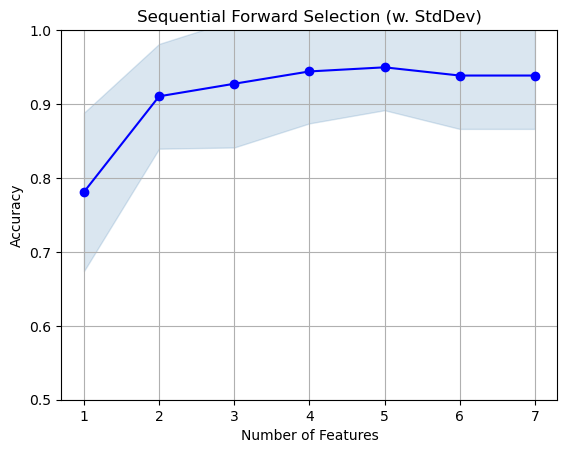

('0', '2', '5', '6', '7', '8', '9')


In [16]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
import matplotlib.pyplot as plt

fig1 = plot_sfs(sfs_forward.get_metric_dict(), 
                ylabel='Accuracy',
                kind='std_dev')

plt.ylim([0.5, 1])
plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()
print(sfs_forward.k_feature_names_)

Accuracy starts to drop after the addition of five features.  
So run again setting `k_features` to five. 

In [17]:
sfs_forward5 = SFS(knn, 
                  k_features=5, 
                  forward=True, 
                  floating=False, 
                  verbose=1,
                  scoring='accuracy',
                  cv=10, n_jobs = -1)

sfs_forward5 = sfs_forward5.fit(X, y)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  13 out of  13 | elapsed:    0.8s finished
Features: 1/5[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.6s finished
Features: 2/5[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  11 out of  11 | elapsed:    0.6s finished
Features: 3/5[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.5s finished
Features: 4/5[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 out of   9 | elapsed:    0.5s finished
Features: 5/5

In [18]:
# look at the features selected
f5_feat = sfs_forward5.k_feature_names_
for i in f5_feat:
    print(wine_DF.columns[int(i)])



Alcohol
Phenols
Flavanoids
Proanth
Color.int


### Run backward selection

In [19]:
sfs_backward = SFS(knn, 
                  k_features=1, 
                  forward=False, 
                  floating=False, 
                  verbose=1,
                  scoring='accuracy',
                  cv=10, n_jobs = -1)

sfs_backward = sfs_backward.fit(X, y)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  13 out of  13 | elapsed:    1.6s finished
Features: 12/1[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.9s finished
Features: 11/1[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  11 out of  11 | elapsed:    0.7s finished
Features: 10/1[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.6s finished
Features: 9/1[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 out of   9 | elapsed:    0.8s finished
Features: 8/1[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    0.7s finished
Features: 7/1[Parallel(n_jobs=-1)]: Using backend 

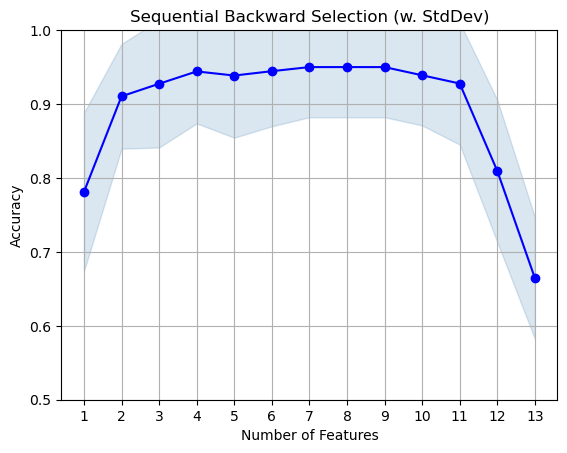

('6',)


In [20]:
fig2 = plot_sfs(sfs_backward.get_metric_dict(), 
                ylabel='Accuracy',
                kind='std_dev')

plt.ylim([0.5, 1])
plt.title('Sequential Backward Selection (w. StdDev)')
plt.grid()
plt.show()
print(sfs_backward.k_feature_names_)

Accuracy levels off after 6 features

In [21]:
sfs_backward = SFS(knn, 
                  k_features=6, 
                  forward=False, 
                  floating=False, 
                  verbose=1,
                  scoring='accuracy',
                  cv=10, n_jobs = -1)

sfs_backward = sfs_backward.fit(X, y)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  13 out of  13 | elapsed:    1.0s finished
Features: 12/6[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.9s finished
Features: 11/6[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  11 out of  11 | elapsed:    0.7s finished
Features: 10/6[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    1.3s finished
Features: 9/6[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 out of   9 | elapsed:    0.6s finished
Features: 8/6[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    0.5s finished
Features: 7/6[Parallel(n_jobs=-1)]: Using backend 

In [22]:
# look at the features selected

b6_feat = sfs_backward.k_feature_names_
for i in b6_feat:
    print(wine_DF.columns[int(i)])


Alcohol
Acl
Flavanoids
Proanth
Color.int
OD


### Check overlap

In [23]:
overlap = set(b6_feat).intersection(set(f5_feat))
for i in overlap:
    print(wine_DF.columns[int(i)])

Alcohol
Proanth
Color.int
Flavanoids
